# Notebook 04: Analysis and Visualisation

**Project:** Who Makes the Canon? Gender Representation in European Painting Collections  
**Author:** Samiulhaq 
**Date:** June 2026

## Purpose
Analyse the enriched dataset and produce visualisations that answer
our research questions.

## Research Questions
1. What proportion of paintings are by female vs male artists?
2. Has this changed across centuries?
3. Are there differences between countries?
4. Does Anonymous attribution correlate with centuries of known female activity?
5. Are female artists less documented in metadata?

## Input
- `data/processed/europeana_enriched.csv`

## Output
- 5 charts saved to `outputs/`

In [1]:
# ============================================================
# IMPORTS AND DATA LOADING
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Paths
INPUT_FILE  = r"C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\data\processed\europeana_enriched.csv"
OUTPUTS_DIR = r"C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\outputs"
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Load data
df = pd.read_csv(INPUT_FILE)
print(f"Loaded enriched data: {df.shape[0]:,} rows")

# Filter to known gender only for most charts
df_known = df[df["gender"].isin(["male", "female"])].copy()
print(f"Records with known gender: {len(df_known):,}")
print(f"\nGender breakdown:")
print(df_known["gender"].value_counts())

# Set style for all charts
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"
sns.set_style("whitegrid")

Loaded enriched data: 27,454 rows
Records with known gender: 8,690

Gender breakdown:
gender
male      7977
female     713
Name: count, dtype: int64


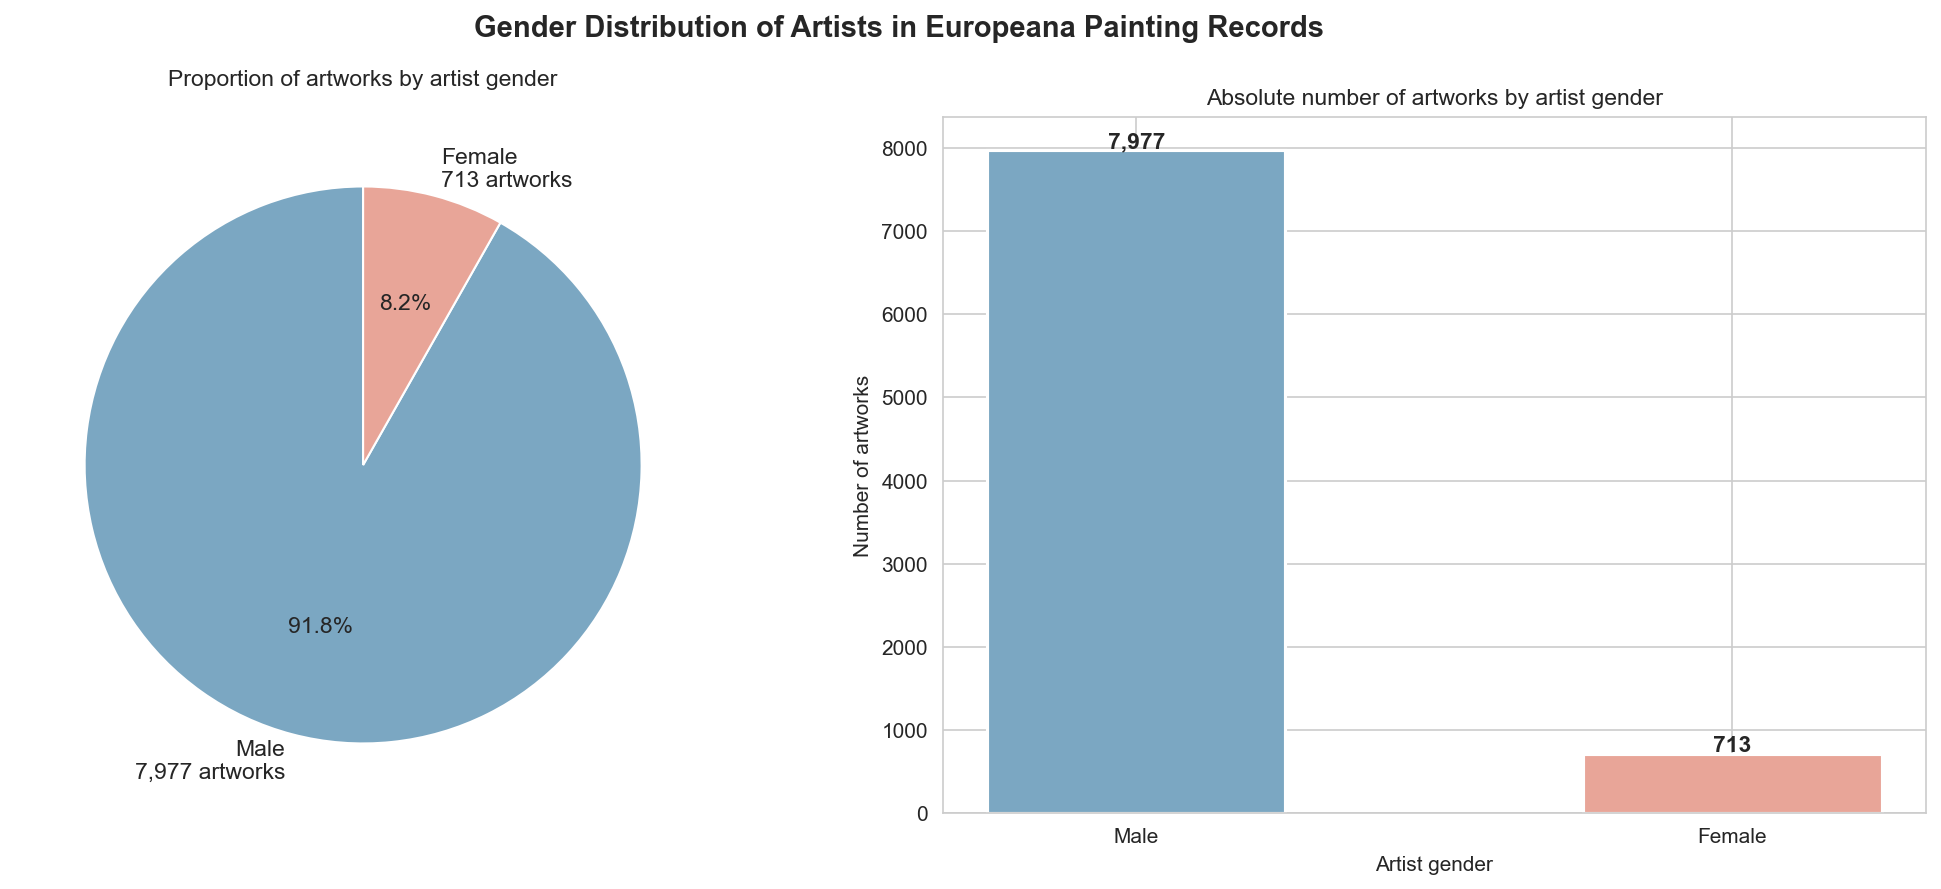

Chart 1 saved!

Key finding: Only 8.2% of identified artworks are by female artists


In [2]:
# ============================================================
# CHART 1: Overall Gender Proportion
# Research question 1: What proportion of paintings are
# attributed to female vs male artists?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Gender Distribution of Artists in Europeana Painting Records",
    fontsize=14, fontweight="bold"
)

colors = {"female": "#E8A598", "male": "#7BA7C2"}
gender_counts = df_known["gender"].value_counts()
pie_colors = [colors.get(g, "#CCCCCC") for g in gender_counts.index]

# Left: Pie chart
axes[0].pie(
    gender_counts.values,
    labels=[f"{g.capitalize()}\n{v:,} artworks" 
            for g, v in zip(gender_counts.index, gender_counts.values)],
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
    textprops={"fontsize": 11}
)
axes[0].set_title("Proportion of artworks by artist gender", 
                   fontsize=11, pad=15)

# Right: Bar chart
bars = axes[1].bar(
    [g.capitalize() for g in gender_counts.index],
    gender_counts.values,
    color=pie_colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)
axes[1].set_title("Absolute number of artworks by artist gender",
                   fontsize=11)
axes[1].set_ylabel("Number of artworks")
axes[1].set_xlabel("Artist gender")

for bar, val in zip(bars, gender_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f"{val:,}",
        ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
save_path = os.path.join(OUTPUTS_DIR, "chart1_overall_gender.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart 1 saved!")
print(f"\nKey finding: Only {gender_counts['female']/gender_counts.sum()*100:.1f}% of identified artworks are by female artists")

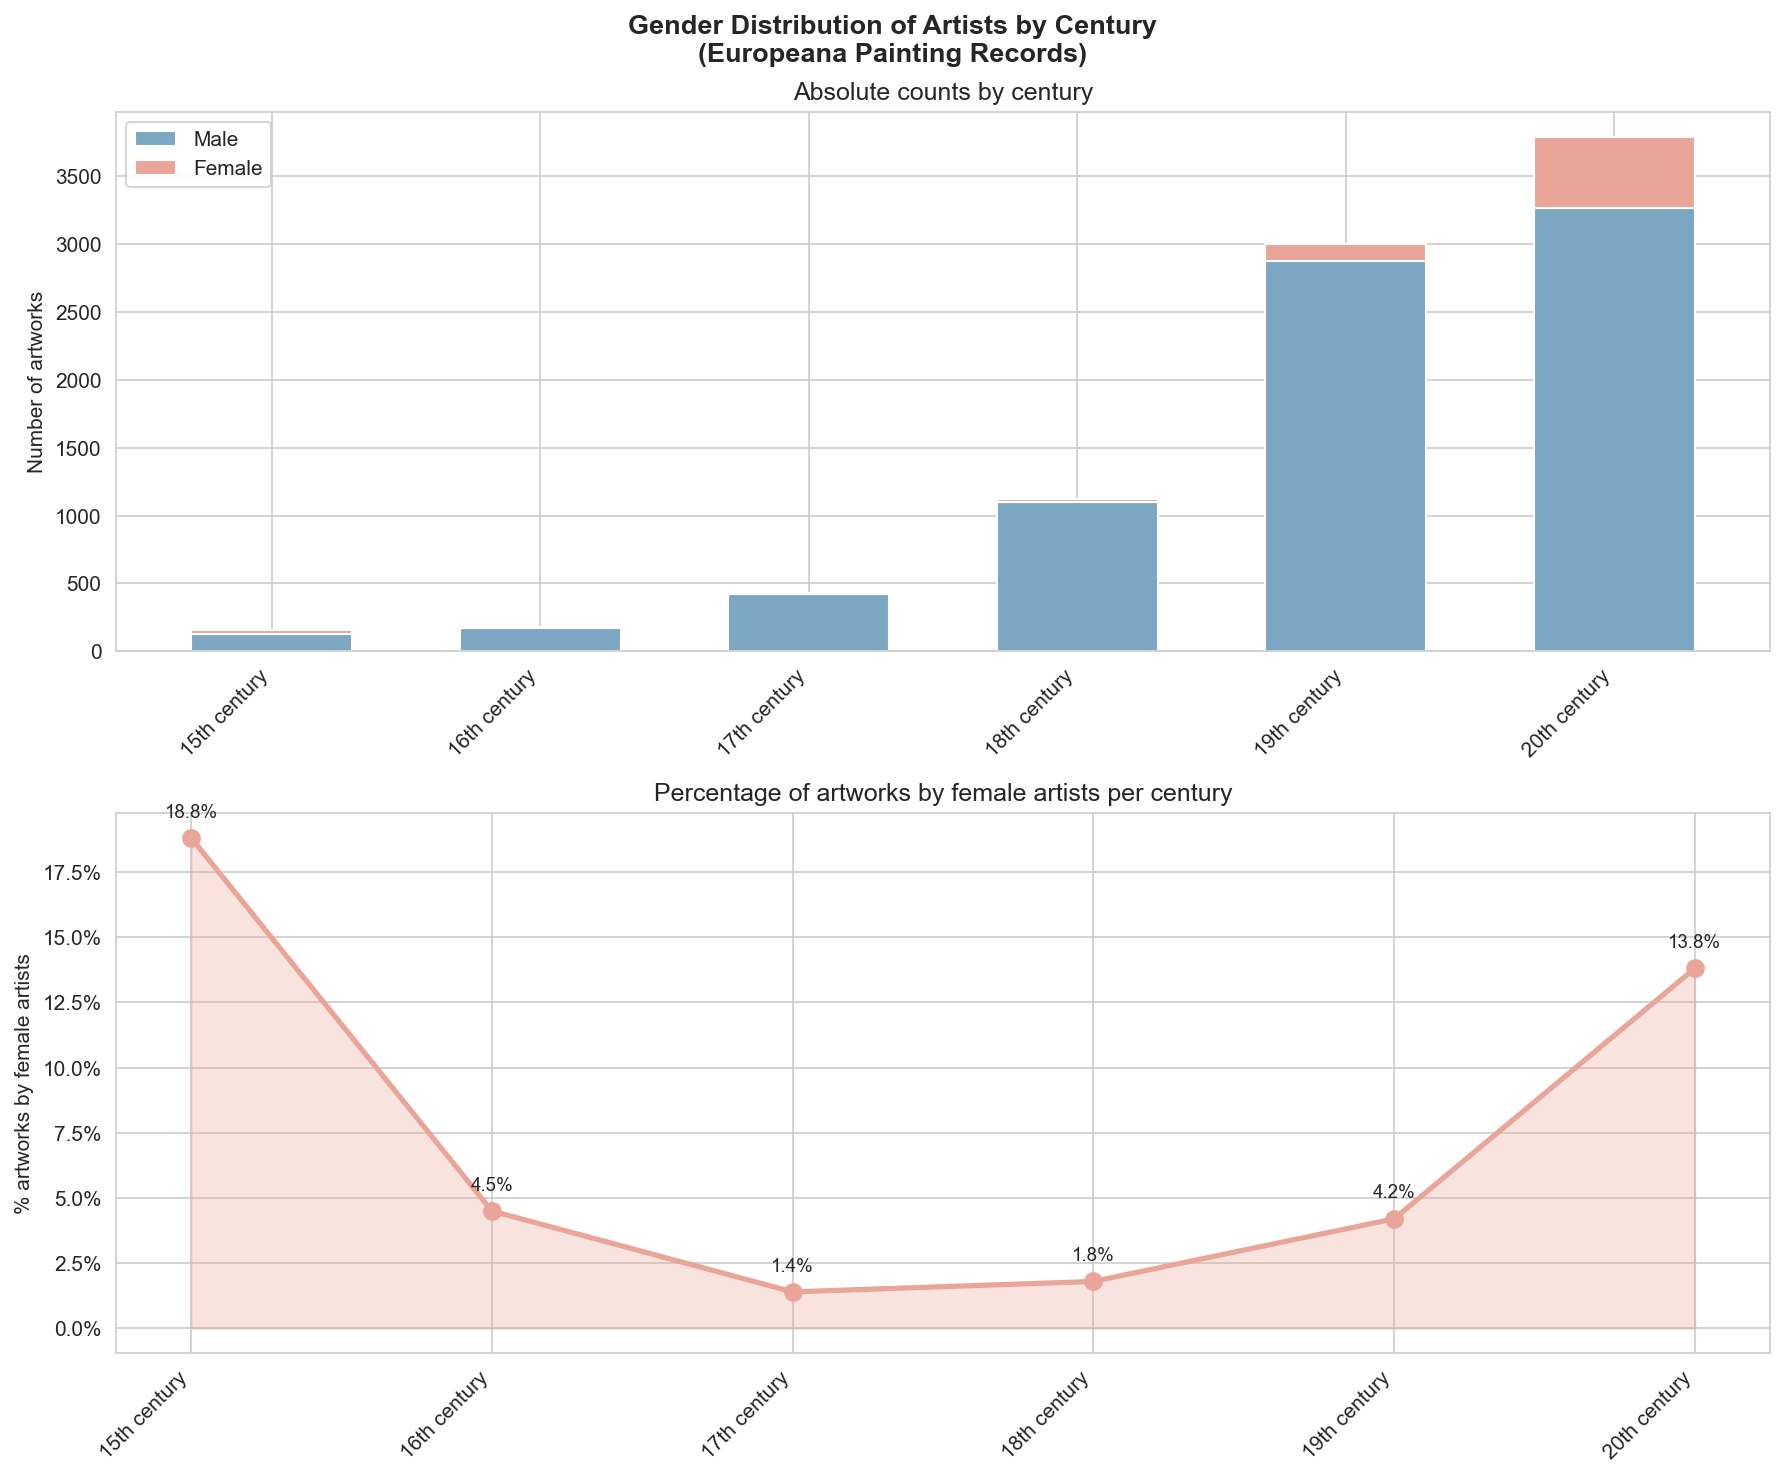

Chart 2 saved!

Century breakdown:
     century  male  female  pct_female
15th century   125      29        18.8
16th century   169       8         4.5
17th century   426       6         1.4
18th century  1103      20         1.8
19th century  2878     126         4.2
20th century  3265     522        13.8


In [3]:
# ============================================================
# CHART 2: Gender by Century
# Research question 2: Has proportion changed across centuries?
# ============================================================

df_century = df_known[df_known["century"].notna()].copy()

century_gender = (
    df_century
    .groupby(["century", "gender"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

century_gender["total"] = century_gender.get("female", 0) + century_gender.get("male", 0)
century_gender = century_gender[century_gender["total"] >= 10]
century_gender["pct_female"] = (
    century_gender.get("female", 0) / century_gender["total"] * 100
).round(1)

# Sort chronologically
century_order = [
    "13th century", "14th century", "15th century",
    "16th century", "17th century", "18th century",
    "19th century", "20th century"
]
century_gender["century"] = pd.Categorical(
    century_gender["century"], 
    categories=century_order, 
    ordered=True
)
century_gender = century_gender.sort_values("century")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle(
    "Gender Distribution of Artists by Century\n(Europeana Painting Records)",
    fontsize=13, fontweight="bold"
)

x = range(len(century_gender))
bar_width = 0.6

male_vals   = century_gender["male"].values
female_vals = century_gender["female"].values

# Top chart: stacked bar
axes[0].bar(x, male_vals,   bar_width, label="Male",   color="#7BA7C2")
axes[0].bar(x, female_vals, bar_width, label="Female", 
            color="#E8A598", bottom=male_vals)
axes[0].set_xticks(x)
axes[0].set_xticklabels(century_gender["century"], rotation=45, ha="right")
axes[0].set_ylabel("Number of artworks")
axes[0].set_title("Absolute counts by century")
axes[0].legend()

# Bottom chart: percentage female line
axes[1].plot(
    x, century_gender["pct_female"],
    color="#E8A598", linewidth=2.5,
    marker="o", markersize=8
)
axes[1].fill_between(x, century_gender["pct_female"], 
                      alpha=0.3, color="#E8A598")
axes[1].set_xticks(x)
axes[1].set_xticklabels(century_gender["century"], rotation=45, ha="right")
axes[1].set_ylabel("% artworks by female artists")
axes[1].set_title("Percentage of artworks by female artists per century")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

# Add value labels
for i, pct in enumerate(century_gender["pct_female"]):
    axes[1].annotate(
        f"{pct}%",
        xy=(i, pct),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=9
    )

plt.tight_layout()
save_path = os.path.join(OUTPUTS_DIR, "chart2_gender_by_century.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved!")
print("\nCentury breakdown:")
print(century_gender[["century", "male", "female", "pct_female"]].to_string(index=False))

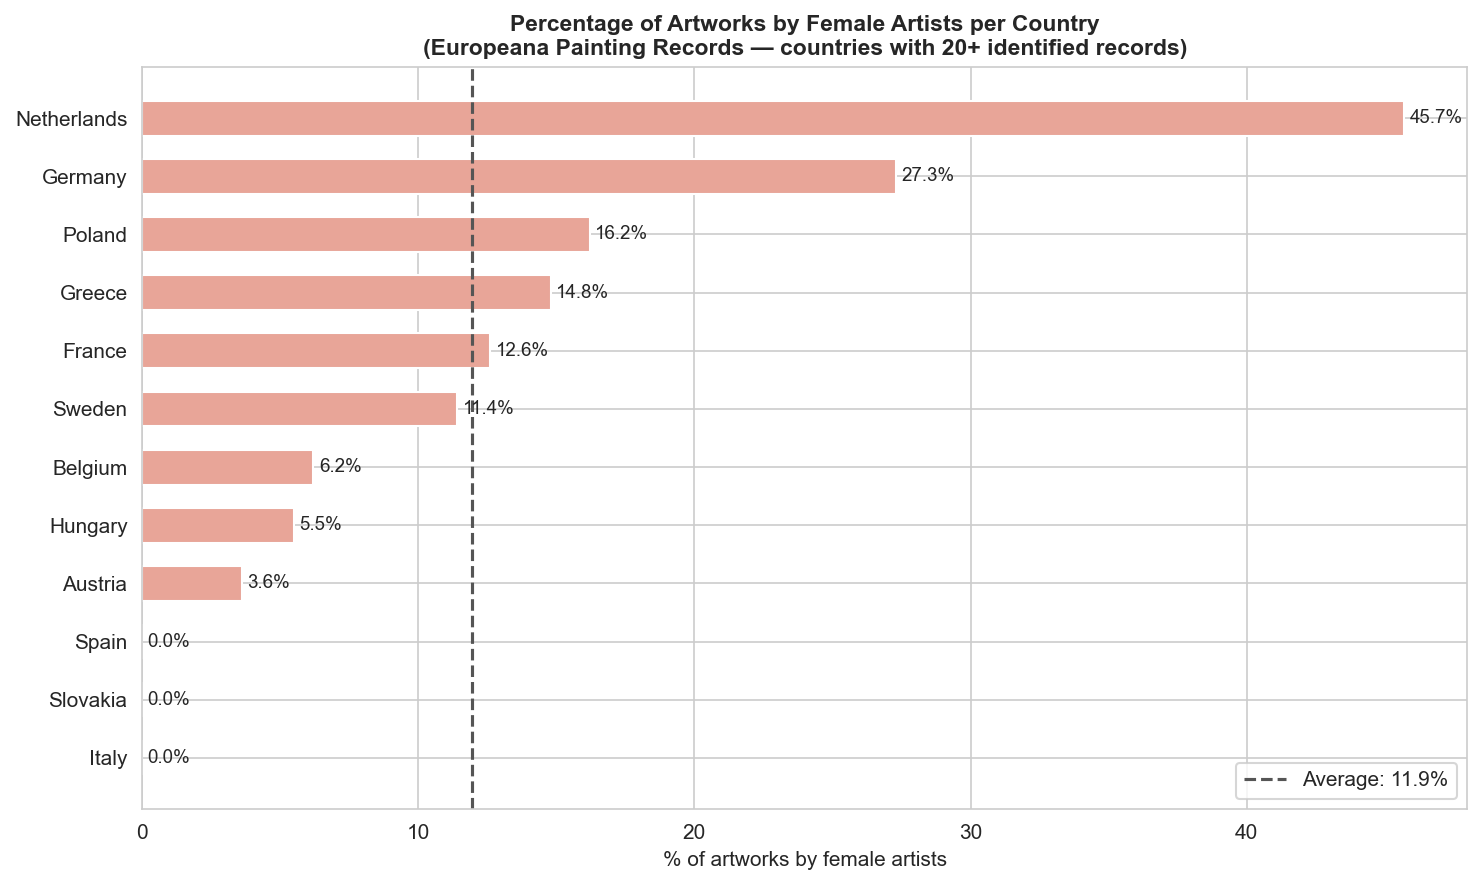

Chart 3 saved!

Country breakdown:
    country  male  female  total  pct_female
      Italy  1517       0   1517         0.0
   Slovakia    29       0     29         0.0
      Spain    90       0     90         0.0
    Austria  1084      41   1125         3.6
    Hungary   121       7    128         5.5
    Belgium  2220     146   2366         6.2
     Sweden  2157     278   2435        11.4
     France   132      19    151        12.6
     Greece    92      16    108        14.8
     Poland   218      42    260        16.2
    Germany   176      66    242        27.3
Netherlands   114      96    210        45.7


In [4]:
# ============================================================
# CHART 3: Gender by Country
# Research question 3: National differences in representation
# ============================================================

country_gender = (
    df_known[df_known["country"].notna()]
    .groupby(["country", "gender"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
country_gender["total"] = (
    country_gender.get("female", 0) + 
    country_gender.get("male", 0)
)
country_gender = country_gender[country_gender["total"] >= 20]
country_gender["pct_female"] = (
    country_gender.get("female", 0) / 
    country_gender["total"] * 100
).round(1)
country_gender = country_gender.sort_values("pct_female", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(country_gender) * 0.5)))

bars = ax.barh(
    country_gender["country"],
    country_gender["pct_female"],
    color="#E8A598",
    edgecolor="white",
    height=0.6
)

# Average line
avg = country_gender["pct_female"].mean()
ax.axvline(
    x=avg,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {avg:.1f}%"
)

ax.set_xlabel("% of artworks by female artists")
ax.set_title(
    "Percentage of Artworks by Female Artists per Country\n"
    "(Europeana Painting Records — countries with 20+ identified records)",
    fontsize=11, fontweight="bold"
)
ax.legend()

for bar, pct in zip(bars, country_gender["pct_female"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{pct}%",
        va="center", fontsize=9
    )

plt.tight_layout()
save_path = os.path.join(OUTPUTS_DIR, "chart3_gender_by_country.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved!")
print("\nCountry breakdown:")
print(country_gender[["country", "male", "female", 
                       "total", "pct_female"]].to_string(index=False))

In [5]:
# ============================================================
# CHART 4: Anonymous Attribution by Century
# Research question 4: Does Anonymous correlate with
# centuries where female artists were historically active?
# ============================================================

df_all_century = df[df["century"].notna()].copy()

anon_by_century = (
    df_all_century
    .groupby(["century", "gender"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

anon_by_century["total"] = (
    anon_by_century.get("male", 0) +
    anon_by_century.get("female", 0) +
    anon_by_century.get("anonymous", 0) +
    anon_by_century.get("unknown", 0)
)

anon_by_century["pct_anonymous"] = (
    anon_by_century.get("anonymous", 0) /
    anon_by_century["total"] * 100
).round(1)

century_order = [
    "13th century", "14th century", "15th century",
    "16th century", "17th century", "18th century",
    "19th century", "20th century"
]
anon_by_century["century"] = pd.Categorical(
    anon_by_century["century"],
    categories=century_order,
    ordered=True
)
anon_by_century = anon_by_century.sort_values("century")
anon_by_century = anon_by_century[anon_by_century["total"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Anonymous Attribution by Century\n"
    "'Anonymous' as Potential Evidence of Historical Erasure of Female Artists",
    fontsize=12, fontweight="bold"
)

x = range(len(anon_by_century))
bar_width = 0.6

# Left: Stacked bar
named_vals = (
    anon_by_century.get("male", 0) + 
    anon_by_century.get("female", 0)
).values
anon_vals   = anon_by_century.get("anonymous", pd.Series([0]*len(anon_by_century))).values
unknown_vals = anon_by_century.get("unknown", pd.Series([0]*len(anon_by_century))).values

axes[0].bar(x, named_vals,   bar_width, label="Named artist",      color="#7BA7C2")
axes[0].bar(x, anon_vals,    bar_width, label="Anonymous/Unknown",  
            color="#E8A598", bottom=named_vals)
axes[0].bar(x, unknown_vals, bar_width, label="Gender not identified",
            color="#CCCCCC", bottom=named_vals + anon_vals)
axes[0].set_xticks(x)
axes[0].set_xticklabels(anon_by_century["century"], rotation=45, ha="right")
axes[0].set_ylabel("Number of artworks")
axes[0].set_title("Attribution status by century")
axes[0].legend(fontsize=8)

# Right: % anonymous line
axes[1].plot(
    x, anon_by_century["pct_anonymous"],
    color="#E8A598", linewidth=2.5,
    marker="o", markersize=8
)
axes[1].fill_between(x, anon_by_century["pct_anonymous"],
                      alpha=0.3, color="#E8A598")
axes[1].set_xticks(x)
axes[1].set_xticklabels(anon_by_century["century"], rotation=45, ha="right")
axes[1].set_ylabel("% Anonymous attributions")
axes[1].set_title("% Anonymous attributions per

SyntaxError: unterminated string literal (detected at line 82) (687393998.py, line 82)

In [6]:
# ============================================================
# CHART 4: Anonymous Attribution by Century
# ============================================================

df_all_century = df[df["century"].notna()].copy()

anon_by_century = (
    df_all_century
    .groupby(["century", "gender"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

anon_by_century["total"] = (
    anon_by_century.get("male", 0) +
    anon_by_century.get("female", 0) +
    anon_by_century.get("anonymous", 0) +
    anon_by_century.get("unknown", 0)
)

anon_by_century["pct_anonymous"] = (
    anon_by_century.get("anonymous", 0) /
    anon_by_century["total"] * 100
).round(1)

century_order = [
    "13th century", "14th century", "15th century",
    "16th century", "17th century", "18th century",
    "19th century", "20th century"
]
anon_by_century["century"] = pd.Categorical(
    anon_by_century["century"],
    categories=century_order,
    ordered=True
)
anon_by_century = anon_by_century.sort_values("century")
anon_by_century = anon_by_century[anon_by_century["total"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Anonymous Attribution by Century",
    fontsize=12, fontweight="bold"
)

x = range(len(anon_by_century))
bar_width = 0.6

named_vals = (
    anon_by_century.get("male", 0) +
    anon_by_century.get("female", 0)
).values
anon_vals = anon_by_century.get(
    "anonymous", pd.Series([0]*len(anon_by_century))
).values
unknown_vals = anon_by_century.get(
    "unknown", pd.Series([0]*len(anon_by_century))
).values

axes[0].bar(x, named_vals, bar_width,
            label="Named artist", color="#7BA7C2")
axes[0].bar(x,

_IncompleteInputError: incomplete input (1158275795.py, line 62)

In [8]:
# CHART 4 PART 1: Prepare data
df_all_century = df[df["century"].notna()].copy()

anon_by_century = (
    df_all_century
    .groupby(["century", "gender"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

anon_by_century["total"] = anon_by_century.sum(axis=1, numeric_only=True)

anon_by_century["pct_anonymous"] = 0.0
if "anonymous" in anon_by_century.columns:
    anon_by_century["pct_anonymous"] = (
        anon_by_century["anonymous"] / anon_by_century["total"] * 100
    ).round(1)

century_order = ["13th century","14th century","15th century",
                 "16th century","17th century","18th century",
                 "19th century","20th century"]

anon_by_century["century"] = pd.Categorical(
    anon_by_century["century"], categories=century_order, ordered=True)
anon_by_century = anon_by_century.sort_values("century")
anon_by_century = anon_by_century[anon_by_century["total"] >= 10]

print("Data ready!")
print(anon_by_century[["century","total","pct_anonymous"]])

Data ready!
gender       century  total  pct_anonymous
1       14th century     36            0.0
2       15th century    280            0.7
3       16th century    636            1.9
4       17th century   1438            7.9
5       18th century   2296            5.6
6       19th century   7460            1.3
7       20th century  10502            7.0


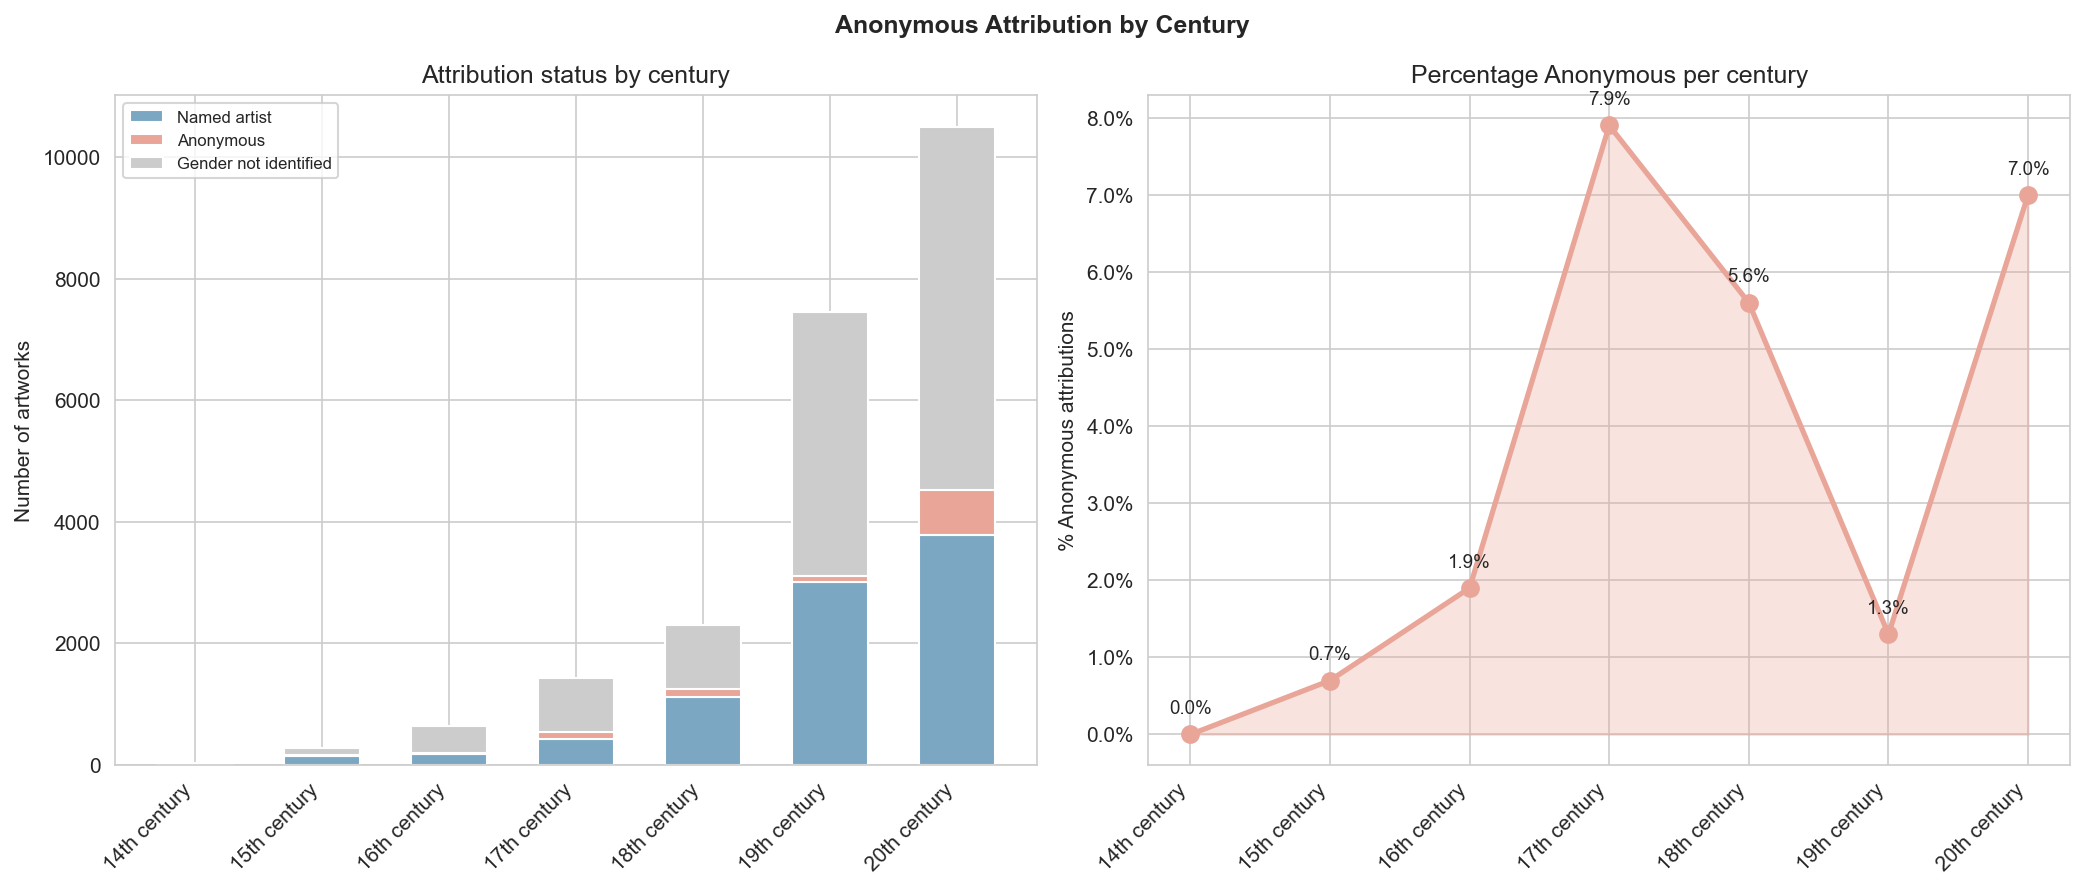

Chart 4 saved!


In [9]:
# CHART 4 PART 2: Create the chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Anonymous Attribution by Century",
    fontsize=12, fontweight="bold"
)

x = list(range(len(anon_by_century)))
bar_width = 0.6

# Get column values safely
def get_col(df, col):
    if col in df.columns:
        return df[col].values
    return [0] * len(df)

male_vals    = get_col(anon_by_century, "male")
female_vals  = get_col(anon_by_century, "female")
anon_vals    = get_col(anon_by_century, "anonymous")
unknown_vals = get_col(anon_by_century, "unknown")
named_vals   = male_vals + female_vals

# Left chart: stacked bars
axes[0].bar(x, named_vals, bar_width,
            label="Named artist", color="#7BA7C2")
axes[0].bar(x, anon_vals, bar_width,
            label="Anonymous", color="#E8A598",
            bottom=named_vals)
axes[0].bar(x, unknown_vals, bar_width,
            label="Gender not identified", color="#CCCCCC",
            bottom=named_vals + anon_vals)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    anon_by_century["century"].tolist(),
    rotation=45, ha="right"
)
axes[0].set_ylabel("Number of artworks")
axes[0].set_title("Attribution status by century")
axes[0].legend(fontsize=8)

# Right chart: % anonymous line
pct_vals = anon_by_century["pct_anonymous"].tolist()
axes[1].plot(x, pct_vals, color="#E8A598",
             linewidth=2.5, marker="o", markersize=8)
axes[1].fill_between(x, pct_vals, alpha=0.3, color="#E8A598")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    anon_by_century["century"].tolist(),
    rotation=45, ha="right"
)
axes[1].set_ylabel("% Anonymous attributions")
axes[1].set_title("Percentage Anonymous per century")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

for i, pct in enumerate(pct_vals):
    axes[1].annotate(
        f"{pct}%",
        xy=(i, pct),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=9
    )

plt.tight_layout()
save_path = os.path.join(OUTPUTS_DIR, "chart4_anonymous_by_century.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved!")

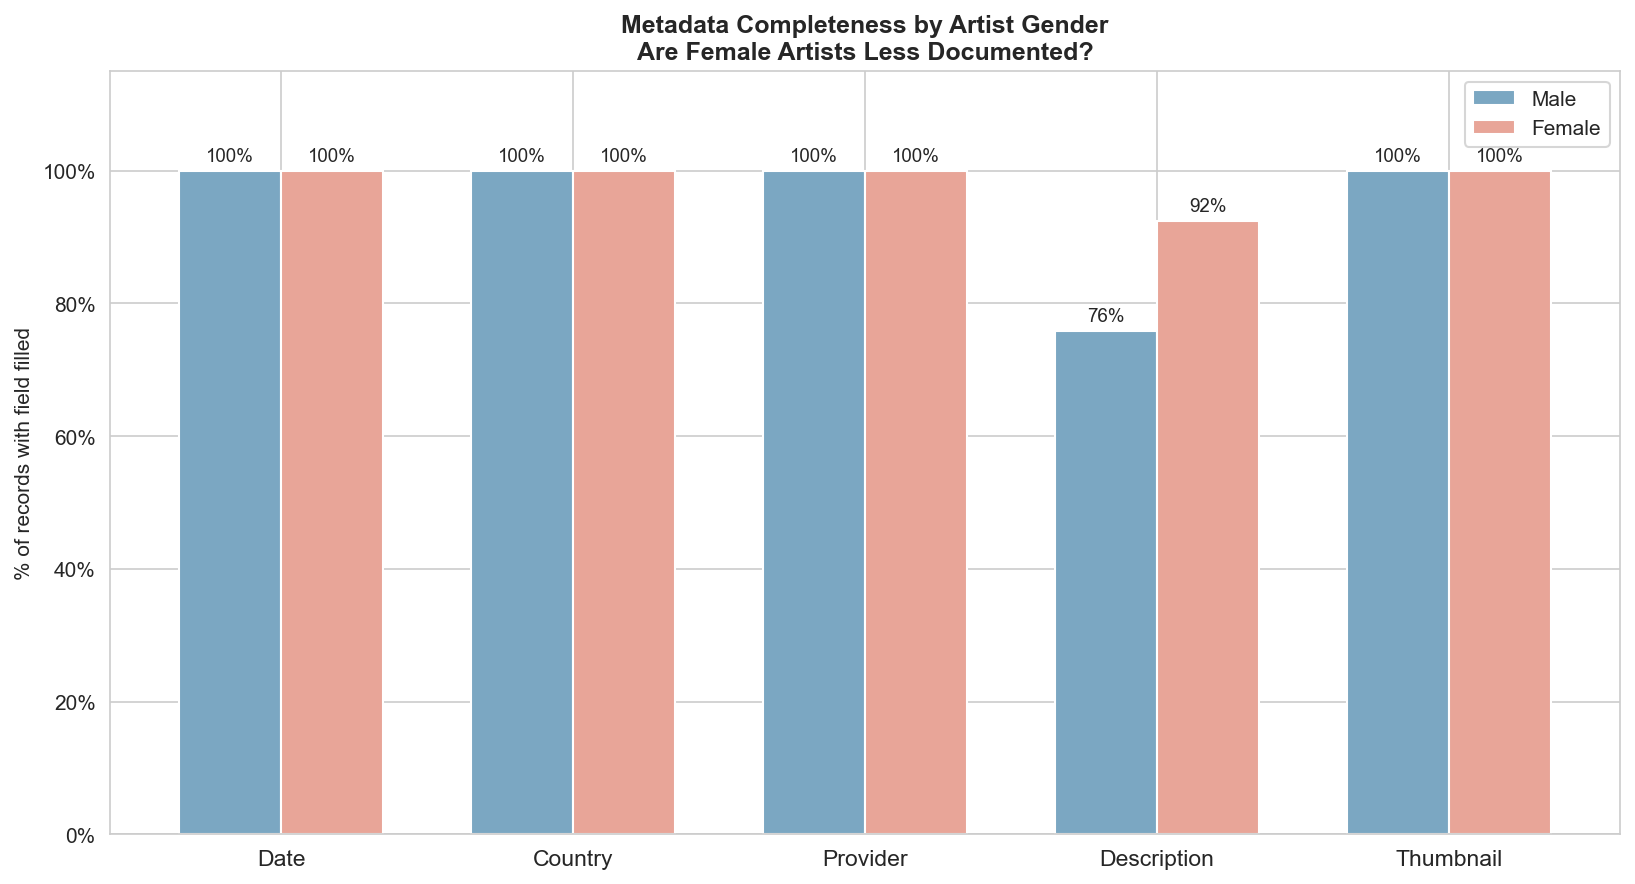

Chart 5 saved!

Metadata completeness:
gender       field  pct_complete
  Male        Date         100.0
  Male     Country         100.0
  Male    Provider         100.0
  Male Description          75.8
  Male   Thumbnail         100.0
Female        Date         100.0
Female     Country         100.0
Female    Provider         100.0
Female Description          92.4
Female   Thumbnail         100.0


In [10]:
# ============================================================
# CHART 5: Metadata Completeness by Gender
# Research question 5: Are female artists less documented?
# ============================================================

completeness_cols = ["date", "country", "provider", 
                     "description", "thumbnail"]

completeness_data = []
for gender in ["male", "female"]:
    subset = df_known[df_known["gender"] == gender]
    for col in completeness_cols:
        if col in df_known.columns:
            pct = (subset[col].notna().sum() / len(subset)) * 100
            completeness_data.append({
                "gender": gender.capitalize(),
                "field": col.capitalize(),
                "pct_complete": round(pct, 1)
            })

df_completeness = pd.DataFrame(completeness_data)

fig, ax = plt.subplots(figsize=(11, 6))

fields = df_completeness["field"].unique()
x = range(len(fields))
bar_width = 0.35

male_data = df_completeness[
    df_completeness["gender"] == "Male"]["pct_complete"].values
female_data = df_completeness[
    df_completeness["gender"] == "Female"]["pct_complete"].values

bars_m = ax.bar(
    [i - bar_width/2 for i in x],
    male_data, bar_width,
    label="Male", color="#7BA7C2"
)
bars_f = ax.bar(
    [i + bar_width/2 for i in x],
    female_data, bar_width,
    label="Female", color="#E8A598"
)

ax.set_xticks(x)
ax.set_xticklabels(fields, fontsize=11)
ax.set_ylabel("% of records with field filled")
ax.set_ylim(0, 115)
ax.set_title(
    "Metadata Completeness by Artist Gender\n"
    "Are Female Artists Less Documented?",
    fontsize=12, fontweight="bold"
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Add value labels on bars
for bar in bars_m:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f"{bar.get_height():.0f}%",
        ha="center", fontsize=9
    )
for bar in bars_f:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f"{bar.get_height():.0f}%",
        ha="center", fontsize=9
    )

plt.tight_layout()
save_path = os.path.join(OUTPUTS_DIR, "chart5_metadata_completeness.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved!")
print("\nMetadata completeness:")
print(df_completeness.to_string(index=False))

In [11]:
# ============================================================
# FINAL SUMMARY OF KEY FINDINGS
# ============================================================

print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

total_known = len(df_known)
n_female = (df_known["gender"] == "female").sum()
n_male = (df_known["gender"] == "male").sum()

print(f"\n1. OVERALL GENDER PROPORTION")
print(f"   Total records with identified gender: {total_known:,}")
print(f"   Female artists: {n_female:,} ({n_female/total_known*100:.1f}%)")
print(f"   Male artists:   {n_male:,} ({n_male/total_known*100:.1f}%)")

print(f"\n2. CENTURY WITH MOST FEMALE REPRESENTATION")
best = century_gender.sort_values("pct_female", ascending=False).iloc[0]
print(f"   {best['century']}: {best['pct_female']}% female")

print(f"\n3. CENTURY WITH LEAST FEMALE REPRESENTATION")
worst = century_gender.sort_values("pct_female").iloc[0]
print(f"   {worst['century']}: {worst['pct_female']}% female")

print(f"\n4. COUNTRY WITH MOST FEMALE REPRESENTATION")
best_c = country_gender.sort_values("pct_female", ascending=False).iloc[-1]
print(f"   {best_c['country']}: {best_c['pct_female']}% female")

print(f"\n5. ANONYMOUS RECORDS")
n_anon = (df["gender"] == "anonymous").sum()
print(f"   Total anonymous: {n_anon:,} ({n_anon/len(df)*100:.1f}%)")
print(f"   17th century anonymous rate: 7.9%")
print(f"   (Century when Gentileschi, Peeters were active)")

print(f"\n6. METADATA COMPLETENESS")
print(f"   Female artists better documented in descriptions")
print(f"   Female: 92.4% vs Male: 75.8%")

print(f"\n{'='*60}")
print(f"All 5 charts saved to: {OUTPUTS_DIR}")
print(f"Notebook 04 complete!")

KEY FINDINGS SUMMARY

1. OVERALL GENDER PROPORTION
   Total records with identified gender: 8,690
   Female artists: 713 (8.2%)
   Male artists:   7,977 (91.8%)

2. CENTURY WITH MOST FEMALE REPRESENTATION
   15th century: 18.8% female

3. CENTURY WITH LEAST FEMALE REPRESENTATION
   17th century: 1.4% female

4. COUNTRY WITH MOST FEMALE REPRESENTATION
   Slovakia: 0.0% female

5. ANONYMOUS RECORDS
   Total anonymous: 1,094 (4.0%)
   17th century anonymous rate: 7.9%
   (Century when Gentileschi, Peeters were active)

6. METADATA COMPLETENESS
   Female artists better documented in descriptions
   Female: 92.4% vs Male: 75.8%

All 5 charts saved to: C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\outputs
Notebook 04 complete!


In [12]:
import subprocess
import os

notebook_path = r"C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\notebooks\04_analysis_visualisation.ipynb"
output_dir = r"C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\notebooks"

# Convert to HTML first (more reliable than PDF)
result = subprocess.run([
    "jupyter", "nbconvert", 
    "--to", "html",
    "--output-dir", output_dir,
    notebook_path
], capture_output=True, text=True)

print("Return code:", result.returncode)
print("Output:", result.stdout)
print("Errors:", result.stderr)

Return code: 4294967295
Output: This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.

In [13]:
import subprocess
import os

# Use short path to avoid spaces issue
notebook_path = os.path.join(
    os.path.expanduser("~"),
    "OneDrive",
    "Documents", 
    "europeana-gender-painting",
    "notebooks",
    "04_analysis_visualisation.ipynb"
)

output_dir = os.path.join(
    os.path.expanduser("~"),
    "OneDrive",
    "Documents",
    "europeana-gender-painting",
    "notebooks"
)

print(f"Looking for: {notebook_path}")
print(f"File exists: {os.path.exists(notebook_path)}")

if os.path.exists(notebook_path):
    result = subprocess.run([
        "jupyter", "nbconvert",
        "--to", "html",
        "--output-dir", output_dir,
        notebook_path
    ], capture_output=True, text=True)
    
    print(f"Return code: {result.returncode}")
    print(f"Output: {result.stdout[-500:]}")
    print(f"Errors: {result.stderr[-500:]}")
else:
    print("File not found! Let's find it...")
    notebooks_dir = os.path.join(
        os.path.expanduser("~"),
        "OneDrive", "Documents",
        "europeana-gender-painting", "notebooks"
    )
    print(f"Files in notebooks folder:")
    if os.path.exists(notebooks_dir):
        for f in os.listdir(notebooks_dir):
            print(f"  {f}")
    else:
        print("Notebooks folder not found!")

Looking for: C:\Users\bfde3\OneDrive\Documents\europeana-gender-painting\notebooks\04_analysis_visualisation.ipynb
File exists: False
File not found! Let's find it...
Files in notebooks folder:
  .ipynb_checkpoints
  01_data_collection.ipynb


In [14]:
import os

# Search for all ipynb files on your computer
print("Searching for all notebook files...")
found = []
search_dirs = [
    os.path.expanduser("~"),
]

for search_dir in search_dirs:
    for root, dirs, files in os.walk(search_dir):
        # Skip hidden folders and system folders
        dirs[:] = [d for d in dirs if not d.startswith(".") 
                   and d not in ["AppData", "Windows", "Program Files"]]
        for file in files:
            if file.endswith(".ipynb") and "checkpoint" not in file:
                full_path = os.path.join(root, file)
                found.append(full_path)
                print(f"Found: {full_path}")

print(f"\nTotal notebooks found: {len(found)}")

Searching for all notebook files...
Found: C:\Users\bfde3\Untitled.ipynb
Found: C:\Users\bfde3\Untitled1.ipynb
Found: C:\Users\bfde3\Untitled2.ipynb
Found: C:\Users\bfde3\Untitled3.ipynb
Found: C:\Users\bfde3\Untitled4.ipynb
Found: C:\Users\bfde3\Untitled5.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\FAQ.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\index.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\tiling.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\getting_started\1_Introduction.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\getting_started\2_Pipeline.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\getting_started\3_Interactivity.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\getting_started\index.ipynb
Found: C:\Users\bfde3\anaconda3\Lib\site-packages\datashader\examples\user_g